# LAB02: Predicciones de los Resultadis de las ELecciones de Portugal 2019

El dataset usado fue: https://archive.ics.uci.edu/dataset/581/simulated+data+for+survival+modelling. ElectionData.csv contiene información en tiempo real sobre los resultados electorales. El objetivo de este lab es predecir los Resuktados Finales de las Elecciones basándonos en variables como votos en blanco, porcentajes de participación y resultados previos.

##1. Cargar Datos
Seleccionamos las columnas numéricas que representan votos, porcentajes y datos históricos.
Usamos pandas únicamente para leer el archivo CSV y manejar los nombres de las columnas fácilmente. Luego, convertimos todo a matrices de numpy.

In [309]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [310]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librería para manipulación y analisis de datos
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [311]:
#recupera los datos con pandas, especificando que pueden estar separados por uno o más espacios '\s+' y que el dataset no tiene cabeceras
df = pd.read_csv('/content/gdrive/MyDrive/SIS420/ElectionData.csv')
# Verificamos que ahora sí existan más de 20 columnas sin valores nulos y los tipos de datos
print(df.info())
# usamos solo los datos que sean números
data_x = [
    'totalMandates', 'availableMandates', 'numParishes', 'numParishesApproved',
    'blankVotes', 'blankVotesPercentage', 'nullVotes', 'nullVotesPercentage',
    'votersPercentage', 'subscribedVoters', 'totalVoters', 'pre.blankVotes',
    'pre.blankVotesPercentage', 'pre.nullVotes', 'pre.nullVotesPercentage',
    'pre.votersPercentage', 'pre.subscribedVoters', 'pre.totalVoters',
    'Mandates', 'Percentage', 'validVotesPercentage', 'Votes', 'Hondt'
]
X = df[data_x].values #valores de las columnas que nos sirven
y = df['FinalMandates'].values #la columna que hay que predecir
m = y.size
print(m)
# imprimimos cantidad de características
n = X.shape[1]
print(n)

# Imprimir algunos puntos de datos para verificar la carga
# X[:,0] es la columna que será de unos, X[:,1] es la primera característica física
print('{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'X[:,3]', 'X[:,4]', 'y'))
print('-'*64)
for i in range(10):
    # Usamos .4f para mostrar 4 decimales
    print('{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:12.4f}'.format(X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], y[i]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21643 entries, 0 to 21642
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TimeElapsed               21643 non-null  int64  
 1   time                      21643 non-null  object 
 2   territoryName             21643 non-null  object 
 3   totalMandates             21643 non-null  int64  
 4   availableMandates         21643 non-null  int64  
 5   numParishes               21643 non-null  int64  
 6   numParishesApproved       21643 non-null  int64  
 7   blankVotes                21643 non-null  int64  
 8   blankVotesPercentage      21643 non-null  float64
 9   nullVotes                 21643 non-null  int64  
 10  nullVotesPercentage       21643 non-null  float64
 11  votersPercentage          21643 non-null  float64
 12  subscribedVoters          21643 non-null  int64  
 13  totalVoters               21643 non-null  int64  
 14  pre.bl

Como podemos observar nuestro dataset tiene 21643 instacias y 23 características con las que trabajaremos (solo quitamos las columnas de tiempos y que tenían tipo de dato $object$), además de la columna que vamos a predecir, llamada `FinalMandates`.

Dividiremos el dataset manualmente (80% entrenamiento, 20% prueba), para probar la efectividad con datos que el modelo no ha visto.


In [312]:
m_entren = int(0.8 * m)
X_entren, X_prueba = X[:m_entren], X[m_entren:]
y_entren, y_prueba = y[:m_entren], y[m_entren:]


print(f"Ejemplos de entrenamiento: {X_entren.shape[0]}")
print(f"Ejemplos de prueba: {X_entren.shape[0]}")
print(f"Número de características (n): {n}")

Ejemplos de entrenamiento: 17314
Ejemplos de prueba: 17314
Número de características (n): 23


## 2. Normalización de Características
Como las variables tienen escalas muy diferentes, el Descenso por el Gradiente tardaría mucho en converger o fallaría. La normalización ajusta los datos para que tengan media 0 y desviación estándar 1.

In [313]:
def featureNormalize(X):
    X_norm = X.copy() #resguardamos la x original
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Si la desviación es 0, la cambiamos a 1 para evitar la división por cero
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_entren_norm, mu, sigma = featureNormalize(X_entren)

# Añadimos la columna de unos para el término independiente (intercepto)
X_entren_listo = np.concatenate([np.ones((m_entren, 1)), X_entren_norm], axis=1)

## 3. Definición de Funciones de Costo y Descenso por el Gradiente
Estas funciones son las mismas aplicadas en los cuadernillos de Regresión Lineal Múltiple.



In [314]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = []
    theta = theta.copy()
    for i in range(num_iters):
        theta = theta - (alpha / m) * np.dot(X.T, (np.dot(X, theta) - y))
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

## 4. Entrenamiento: Regresión Lineal Multivariable
Entrenamos el primer modelo ajustando los parámetros $\theta$ para minimizar el error.

Text(0.5, 1.0, 'Convergencia del Costo - Regresión Lineal')

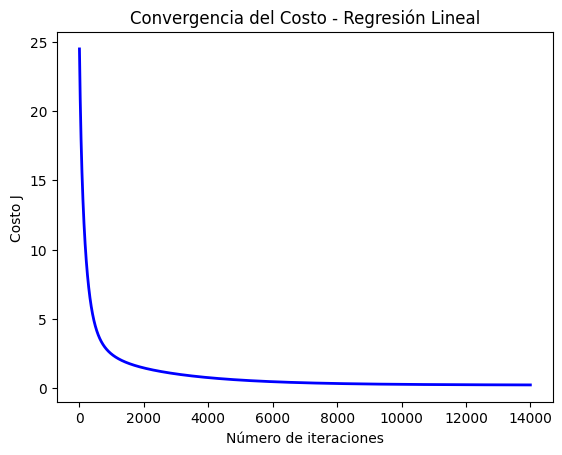

In [315]:
# Configuración de hiperparámetros
alpha = 0.001
num_iters = 14000

# Inicializar theta con ceros
theta_lin = np.zeros(X_entren_listo.shape[1])

# Ejecutar el descenso por el gradiente
theta_lin, J_history_lin = gradientDescentMulti(X_entren_listo, y_entren, theta_lin, alpha, num_iters)

# Gráfico de costo
pyplot.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - Regresión Lineal')

## 5. Entrenamiento: Regresión Polinómica
La regresión polinómica no requiere un algoritmo nuevo. Lo que hacemos es crear nuevas características elevando las originales al cuadrado ($x^2$). Esto permite que el modelo aprenda relaciones curvas entre el número de votos y los mandatos finales. Al final, aplicamos el mismo Descenso por el Gradiente.

Text(0.5, 1.0, 'Convergencia del Costo - Regresión Polinómica')

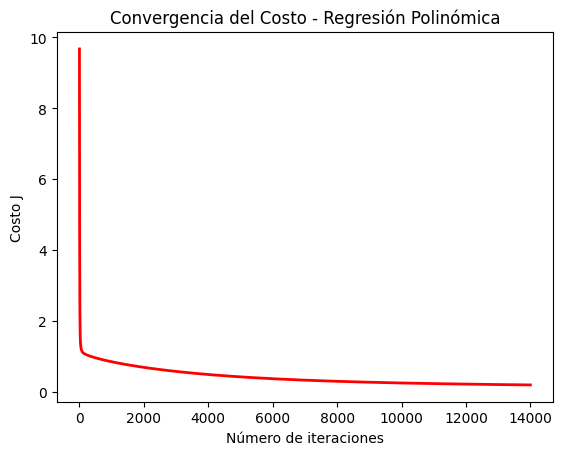

In [316]:
# Generamos características polinómicas de grado 2 (X y X^2)
X_entren_poly = np.concatenate([X_entren_norm, np.square(X_entren_norm)], axis=1)
X_entren_poly_listo = np.concatenate([np.ones((y_entren.size, 1)), X_entren_poly], axis=1)

# Inicializar theta (ahora es más largo porque tenemos más características)
theta_poly = np.zeros(X_entren_poly_listo.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_entren_poly_listo, y_entren, theta_poly, alpha, num_iters)

# Gráfico de costo polinómico
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='red')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - Regresión Polinómica')

## 6. Modelo 3: Ecuación de la Normal
Este método no usa iteraciones ni normalización. Encuentra el valor óptimo de $\theta$ directamente resolviendo una ecuación matricial. Es muy efectivo cuando el número de características no es excesivamente grande (como en nuestro caso $n=23$).


In [317]:
#recupera los datos con pandas, especificando que pueden estar separados por uno o más espacios '\s+' y que el dataset no tiene cabeceras
df = pd.read_csv('/content/gdrive/MyDrive/SIS420/ElectionData.csv')
# usamos solo los datos que sean números
data_x = [
    'totalMandates', 'availableMandates', 'numParishes', 'numParishesApproved',
    'blankVotes', 'blankVotesPercentage', 'nullVotes', 'nullVotesPercentage',
    'votersPercentage', 'subscribedVoters', 'totalVoters', 'pre.blankVotes',
    'pre.blankVotesPercentage', 'pre.nullVotes', 'pre.nullVotesPercentage',
    'pre.votersPercentage', 'pre.subscribedVoters', 'pre.totalVoters',
    'Mandates', 'Percentage', 'validVotesPercentage', 'Votes', 'Hondt'
]
X = df[data_x].values #valores de las columnas que nos sirven
y = df['FinalMandates'].values #la columna que hay que predecir
m = y.size
print(m)
# imprimimos cantidad de características
n = X.shape[1]
print(n)

# Imprimir algunos puntos de datos para verificar la carga
# X[:,0] es la columna que será de unos, X[:,1] es la primera característica física
print('{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'X[:,3]', 'X[:,4]', 'y'))
print('-'*64)
for i in range(10):
    # Usamos .4f para mostrar 4 decimales
    print('{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:12.4f}'.format(X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], y[i]))

21643
23
    X[:,0]    X[:,1]    X[:,2]    X[:,3]    X[:,4]         y
----------------------------------------------------------------
    0.0000  226.0000 3092.0000 1081.0000 9652.0000    106.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000     77.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000     19.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      5.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000     12.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      4.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      1.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      0.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      0.0000
    0.0000  226.0000 3092.0000 1081.0000 9652.0000      0.0000


In [318]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])
    theta= np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [319]:
# Creamos una versión de X_entren que tenga la columna de unos
X_entren_con_unos = np.concatenate([np.ones((y_entren.size, 1)), X_entren], axis=1)
# Calcula los parametros con la ecuación de la normal
theta_norm = normalEqn(X_entren_con_unos, y_entren);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_norm)));

Theta calculado a partir de la ecuación de la normal: [ 1.07176813e-01 -1.98015511e-02 -4.52357263e-03  1.91533881e-05
 -5.31751910e-06 -1.44571461e-06 -5.18396958e-03 -3.82204410e-07
  3.22209250e-03 -2.38018860e-03 -1.64711733e-07  7.04545227e-07
  3.85663979e-07  2.88128262e-03 -1.75579615e-06  3.84711156e-04
  1.86347974e-03  1.29481615e-07 -4.12073636e-08  3.15979679e-01
 -1.55300763e-02 -1.75573890e-03 -1.14271689e-05  1.08887168e+00]


## 7. Validación y Predicciones (Efectividad)
Realizaremos una comparativa de los tres modelos entrenados. El objetivo es evaluar la precisión de la Regresión Lineal, la Regresión Polinómica y la Ecuación de la Normal utilizando el conjunto de datos de prueba (X_prueba).

No. |    Real |      Lin. |     Poly. |    Normal
-------------------------------------------------------
  1 |       0 |      0.02 |     -0.25 |      0.06
  2 |       0 |      0.02 |     -0.25 |      0.06
  3 |       0 |      0.02 |     -0.25 |      0.06
  4 |       0 |      0.02 |     -0.25 |      0.06
  5 |       0 |      0.02 |     -0.26 |      0.06
  6 |       0 |      0.02 |     -0.27 |      0.06
  7 |       0 |      0.02 |     -0.27 |      0.06
  8 |       0 |      0.02 |     -0.27 |      0.06
  9 |       0 |      0.02 |     -0.27 |      0.06
 10 |       0 |      0.02 |     -0.28 |      0.06
 11 |       3 |      2.83 |      3.99 |      3.12
 12 |       1 |      0.93 |      2.16 |      0.72
 13 |       0 |     -0.01 |      0.70 |     -0.25
 14 |       0 |     -0.01 |      0.27 |     -0.08
 15 |       0 |     -0.01 |      0.19 |     -0.05
 16 |       0 |     -0.00 |      0.09 |     -0.01
 17 |       0 |     -0.00 |      0.01 |      0.02
 18 |       0 |     -0.00 |     -0.02 |     

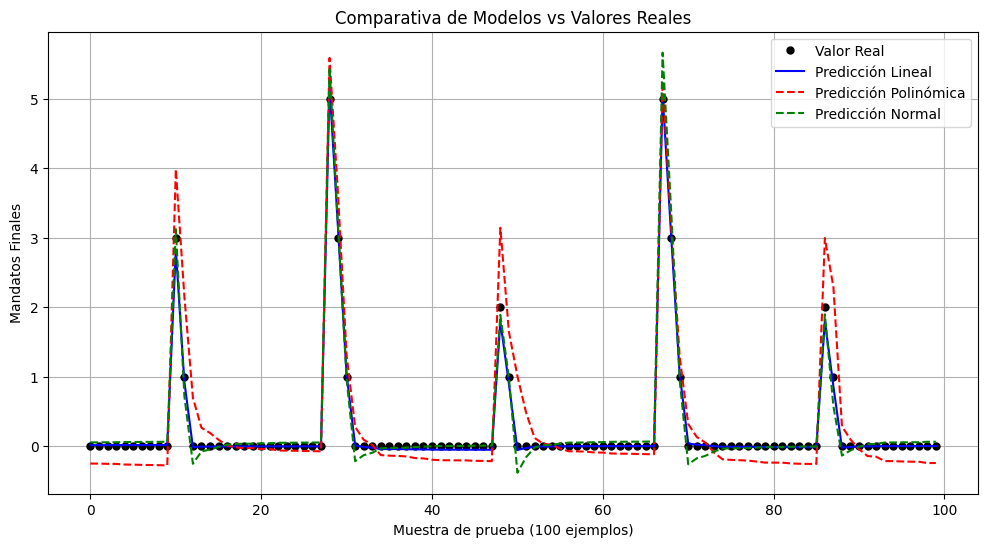

In [320]:
# Preparamos los datos de prueba para cada modelo:
# Para Lineal y Ecuación Normal (usando mu y sigma calculados con X_entren)
X_prueba_norm = (X_prueba - mu) / sigma
X_prueba_ready = np.concatenate([np.ones((y_prueba.size, 1)), X_prueba_norm], axis=1)

# Para Polinómica (mismo grado 2 que en el entrenamiento)
X_prueba_poly = np.concatenate([X_prueba_norm, X_prueba_norm**2], axis=1)
X_prueba_poly_listo = np.concatenate([np.ones((y_prueba.size, 1)), X_prueba_poly], axis=1)

# Para Ecuación de la Normal
X_prueba_norm_unos = np.concatenate([np.ones((y_prueba.size, 1)), X_prueba], axis=1)

# Generamos 100 predicciones
m_mostrar = 100
pred_lin = np.dot(X_prueba_ready[:m_mostrar], theta_lin)
pred_poly = np.dot(X_prueba_poly_listo[:m_mostrar], theta_poly)
pred_norm = np.dot(X_prueba_norm_unos[:m_mostrar], theta_norm)

# Mostramos tabla comparativa de los resultados
print(f"{'No.':>3} | {'Real':>7} | {'Lin.':>9} | {'Poly.':>9} | {'Normal':>9}")
print("-" * 55)
for i in range(20): # Mostramos los primeros 20 en texto para claridad
    print(f"{i+1:>3} | {y_prueba[i]:>7.0f} | {pred_lin[i]:>9.2f} | {pred_poly[i]:>9.2f} | {pred_norm[i]:>9.2f}")

# Gráfico de Efectividad Comparada
pyplot.figure(figsize=(12, 6))
pyplot.plot(y_prueba[:m_mostrar], 'ko', label='Valor Real', markersize=5) #graficamos los datos reales
pyplot.plot(pred_lin, 'b-', label='Predicción Lineal') #graficamos en linea las predicción lineal
pyplot.plot(pred_poly, 'r--', label='Predicción Polinómica') #graficamos en linea las predicción polinómica
pyplot.plot(pred_norm, 'g--', label='Predicción Normal') #graficamos en linea las predicción normal
pyplot.xlabel('Muestra de prueba (100 ejemplos)')
pyplot.ylabel('Mandatos Finales')
pyplot.title('Comparativa de Modelos vs Valores Reales')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

En el gráfico se observa que las líneas de predicción de los tres modelos siguen fielmente la tendencia de los valores reales (puntos negros). Esto confirma que los modelos han logrado capturar la lógica del dataset electoral.
La predicción Lineal (azul) y la Predicción Normal (verde) son casi iguales y son las más certeras referente a los valores reales. Mientras que la Regresión Polinómica (roja) tiende a sobreestimar los valores. Por lo que, concluímos que el modelo lineal es más preciso en este caso.